# Introduction

In a [previous post](https://nipunbatra.github.io/blog/posts/2025-12-01-gemini-api-multimodal.html), we explored Google's Gemini 3 Pro multimodal capabilities. The model showed impressive performance on object detection, segmentation, and complex visual reasoning tasks.

But how does it perform on low-level visual perception tasks? Two recent research projects shed light on limitations of vision language models:

- **[VLMsAreBlind](https://vlmsareblind.github.io/)**: Tests 7 low-level geometric tasks (counting line intersections, nested shapes, etc.) where top models achieved only ~58% accuracy
- **[VLMsAreBiased](https://vlmsarebiased.github.io/)**: Tests whether models rely on memorized knowledge rather than visual evidence when familiar objects are modified (e.g., counting legs on 6-legged cats)

In this notebook, we'll test Gemini 3 Pro on both **real benchmark data** from Hugging Face and **custom-generated test images** to see if Google's latest model has improved on these challenging visual tasks.

## What We'll Test

**Real Benchmark Data:**
- 3 examples from VLMsAreBlind (geometric reasoning)
- 3 examples from VLMsAreBiased (memorization vs. vision)

**Custom Tests - VLMsAreBlind (Low-Level Vision):**
1. Line intersections
2. Touching/overlapping circles
3. Grid row/column counting
4. Nested squares

**Custom Tests - VLMsAreBiased (Memorization vs. Vision):**
1. Modified animal legs (do models see 6 legs or default to "cats have 4 legs"?)
2. Modified brand logos (Adidas with 2 stripes instead of 3)
3. Modified national flags (USA flag with 7 stripes instead of 13)
4. Modified chess positions

Let's find out if Gemini 3 Pro can truly "see" or if it's still relying on learned patterns!

# Setup

In [ ]:
# Install required packages
# !pip install -q google-genai pillow matplotlib numpy datasets

In [10]:
import os
import json
from google import genai
from PIL import Image, ImageDraw, ImageFont
import matplotlib.pyplot as plt
import numpy as np
from io import BytesIO

# Initialize client
if 'GEMINI_API_KEY' not in os.environ:
    raise ValueError(
        "GEMINI_API_KEY not found in environment.\n"
        "Set it with: export GEMINI_API_KEY='your-key'\n"
        "Get your key at: https://aistudio.google.com/apikey"
    )

client = genai.Client(api_key=os.environ['GEMINI_API_KEY'])
MODEL = "models/gemini-3-pro-preview"

print(f"Gemini client initialized")
print(f"Using model: {MODEL}")

%config InlineBackend.figure_format = 'retina'

Gemini client initialized
Using model: models/gemini-3-pro-preview


# Helper Functions

In [16]:
def test_visual_task(image, question, correct_answer, task_name):
    """Test a single visual reasoning task."""
    print(f"\n{'='*80}")
    print(f"Task: {task_name}")
    print(f"{'='*80}")
    
    # Display image
    plt.figure(figsize=(6, 6))
    plt.imshow(image)
    #plt.title(task_name, fontsize=14, fontweight='bold')
    plt.axis('off')
    plt.tight_layout()
    plt.show()
    
    # Ask Gemini
    print(f"\nQuestion: {question}")
    print(f"Correct Answer: {correct_answer}")
    
    response = client.models.generate_content(
        model=MODEL,
        contents=[question + "\n\nAnswer with ONLY the number or short answer, no explanation.", image]
    )
    
    # Handle None response
    if response.text is None:
        print(f"Gemini's Answer: [No response]")
        print(f"\nResult: INCORRECT (No response)")
        print("="*80)
        return False, "[No response]"
    
    model_answer = response.text.strip()
    print(f"Gemini's Answer: {model_answer}")
    
    # Check correctness (case-insensitive comparison)
    correct_str = str(correct_answer).lower()
    answer_str = str(model_answer).lower()
    is_correct = correct_str in answer_str or answer_str in correct_str
    
    result = "CORRECT" if is_correct else "INCORRECT"
    print(f"\nResult: {result}")
    print("="*80)
    
    return is_correct, model_answer

def create_results_summary(results):
    """Create a summary table of all results."""
    print(f"\n\n{'='*80}")
    print("FINAL RESULTS SUMMARY")
    print(f"{'='*80}\n")
    
    total_correct = sum(1 for r in results if r['correct'])
    total_tasks = len(results)
    accuracy = 100 * total_correct / total_tasks if total_tasks > 0 else 0
    
    print(f"Overall Accuracy: {total_correct}/{total_tasks} ({accuracy:.1f}%)\n")
    
    # Group by category
    categories = {}
    for r in results:
        cat = r['category']
        if cat not in categories:
            categories[cat] = {'correct': 0, 'total': 0}
        categories[cat]['total'] += 1
        if r['correct']:
            categories[cat]['correct'] += 1
    
    print("By Category:")
    for cat, stats in categories.items():
        cat_accuracy = 100 * stats['correct'] / stats['total']
        print(f"  {cat}: {stats['correct']}/{stats['total']} ({cat_accuracy:.1f}%)")
    
    print(f"\n{'='*80}")

print("Helper functions loaded")

Helper functions loaded


# Load Real Benchmark Data

Let's load a small subset of actual test images from both benchmarks hosted on Hugging Face.

In [ ]:
from datasets import load_dataset

# Load VLMsAreBlind dataset (line intersections, grids, nested shapes)
print("Loading VLMsAreBlind dataset...")
try:
    vlms_blind = load_dataset("XAI/vlmsareblind", split="valid")
    print(f"✓ Loaded {len(vlms_blind)} examples")
    
    # Sample a few examples from different tasks
    tasks_available = set(vlms_blind['task'])
    print(f"  Tasks available: {', '.join(sorted(tasks_available))}")
except Exception as e:
    print(f"Note: Could not load VLMsAreBlind dataset - {str(e)[:100]}")
    vlms_blind = None

# Load VLMsAreBiased dataset (modified animals, logos, flags)
print("\nLoading VLMsAreBiased dataset...")
try:
    vlms_biased = load_dataset("anvo25/vlms-are-biased", split="main")
    print(f"✓ Loaded {len(vlms_biased)} examples")
    
    # Sample topics
    topics_available = set(vlms_biased['topic'])
    print(f"  Topics available: {', '.join(sorted(topics_available))}")
except Exception as e:
    print(f"Note: Could not load VLMsAreBiased dataset - {str(e)[:100]}")
    vlms_biased = None

## Test Real Examples from VLMsAreBlind

Let's test 2-3 real examples from the VLMsAreBlind benchmark.

In [ ]:
results_real = []

if vlms_blind is not None:
    # Test 3 examples from different tasks
    test_indices = [0, 100, 500]  # Sample from different parts of dataset
    
    for idx in test_indices:
        example = vlms_blind[idx]
        
        # Extract data
        image = example['image']
        prompt = example['prompt']
        ground_truth = example['groundtruth']
        task_name = example['task']
        
        # Test with Gemini
        correct, answer = test_visual_task(
            image,
            prompt,
            ground_truth,
            f"VLMsAreBlind: {task_name} (Example {idx})"
        )
        
        results_real.append({
            'category': 'VLMsAreBlind (Real)',
            'task': task_name,
            'correct': correct,
            'expected': ground_truth,
            'actual': answer
        })
else:
    print("VLMsAreBlind dataset not loaded - skipping tests")

## Test Real Examples from VLMsAreBiased

Now let's test 2-3 real examples from the VLMsAreBiased benchmark.

In [ ]:
if vlms_biased is not None:
    # Test 3 examples from different topics
    test_indices = [0, 50, 100]  # Sample from different parts of dataset
    
    for idx in test_indices:
        example = vlms_biased[idx]
        
        # Extract data
        image = example['image']
        prompt = example['prompt']
        ground_truth = example['ground_truth']
        topic = example['topic']
        sub_topic = example['sub_topic']
        
        # Test with Gemini
        correct, answer = test_visual_task(
            image,
            prompt,
            ground_truth,
            f"VLMsAreBiased: {topic} - {sub_topic} (Example {idx})"
        )
        
        results_real.append({
            'category': 'VLMsAreBiased (Real)',
            'task': f"{topic}: {sub_topic}",
            'correct': correct,
            'expected': ground_truth,
            'actual': answer
        })
else:
    print("VLMsAreBiased dataset not loaded - skipping tests")

# Part 1 (continued): Custom Tests - Low-Level Vision

Now let's test with our own custom-generated images to complement the real benchmark data.

# Part 1: VLMsAreBlind - Low-Level Vision Tests

These tests evaluate whether Gemini 3 Pro can accurately perceive geometric details at a low level.

## Test 1: Line Intersections

Can the model count where two line segments intersect?


Task: Line Intersections (1 intersection)


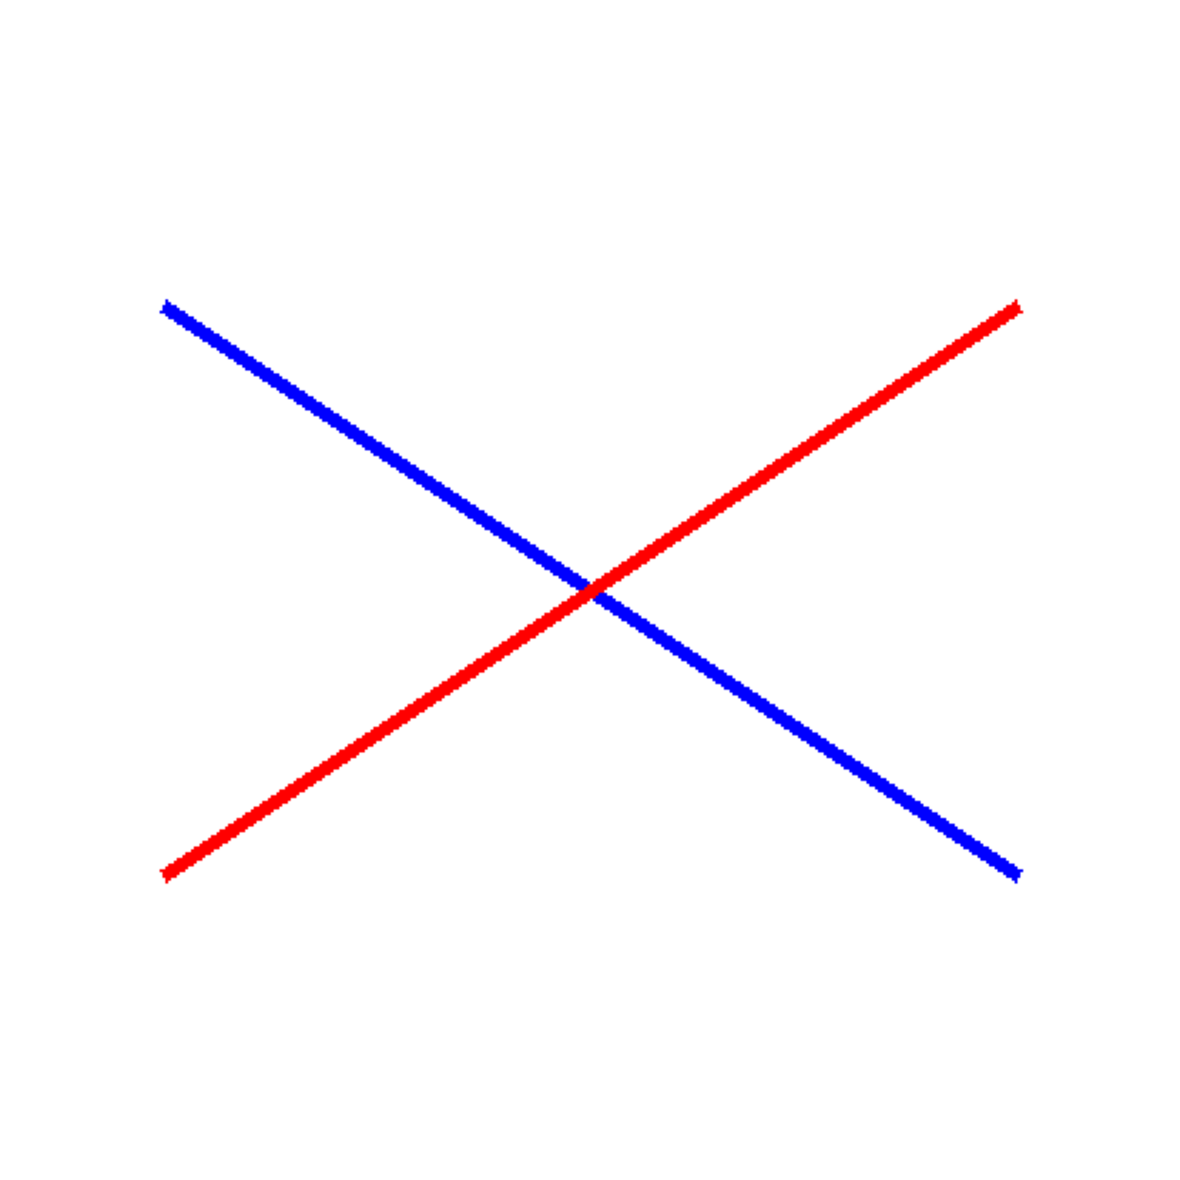


Question: How many times do the blue and red lines intersect?
Correct Answer: 1
Gemini's Answer: 1

Result: CORRECT


In [17]:
results = []

# Create test image: Two lines that intersect once
img = Image.new('RGB', (400, 400), 'white')
draw = ImageDraw.Draw(img)

# Draw two intersecting lines
draw.line([(50, 100), (350, 300)], fill='blue', width=5)
draw.line([(50, 300), (350, 100)], fill='red', width=5)

correct, answer = test_visual_task(
    img,
    "How many times do the blue and red lines intersect?",
    "1",
    "Line Intersections (1 intersection)"
)

results.append({
    'category': 'VLMsAreBlind',
    'task': 'Line Intersections',
    'correct': correct,
    'expected': '1',
    'actual': answer
})


Task: Line Intersections (0 intersections - parallel)


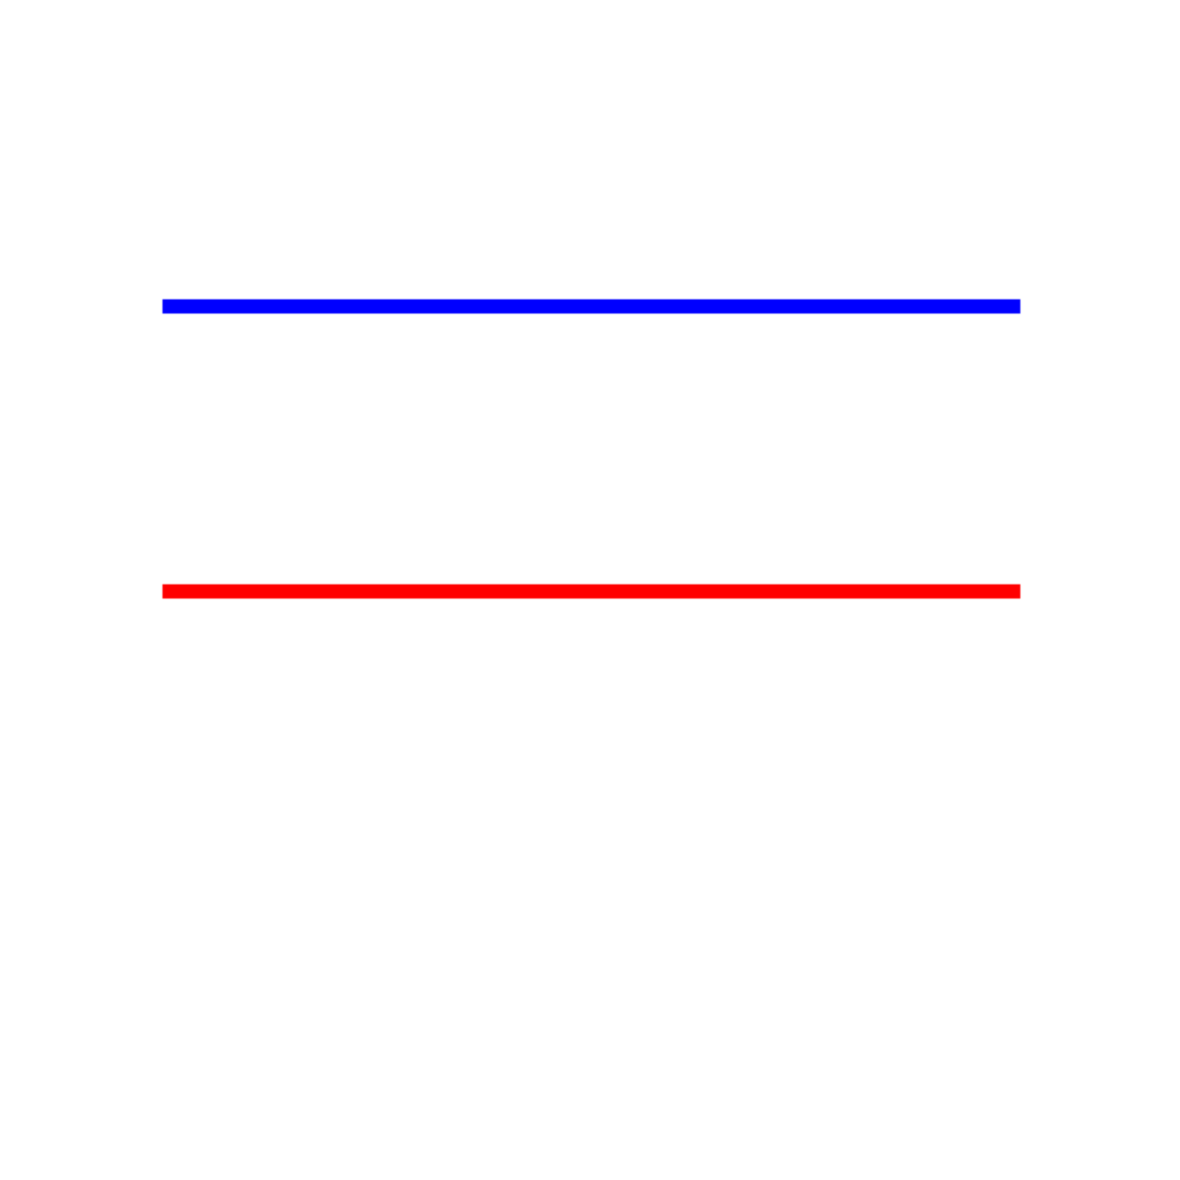


Question: How many times do the blue and red lines intersect?
Correct Answer: 0
Gemini's Answer: 0

Result: CORRECT


In [18]:
# Test 2: Lines that don't intersect
img2 = Image.new('RGB', (400, 400), 'white')
draw2 = ImageDraw.Draw(img2)

# Draw two parallel lines
draw2.line([(50, 100), (350, 100)], fill='blue', width=5)
draw2.line([(50, 200), (350, 200)], fill='red', width=5)

correct, answer = test_visual_task(
    img2,
    "How many times do the blue and red lines intersect?",
    "0",
    "Line Intersections (0 intersections - parallel)"
)

results.append({
    'category': 'VLMsAreBlind',
    'task': 'Line Intersections',
    'correct': correct,
    'expected': '0',
    'actual': answer
})

## Test 2: Touching Circles

Can the model distinguish between overlapping, touching, and separated circles?


Task: Circle Relationship (overlapping)


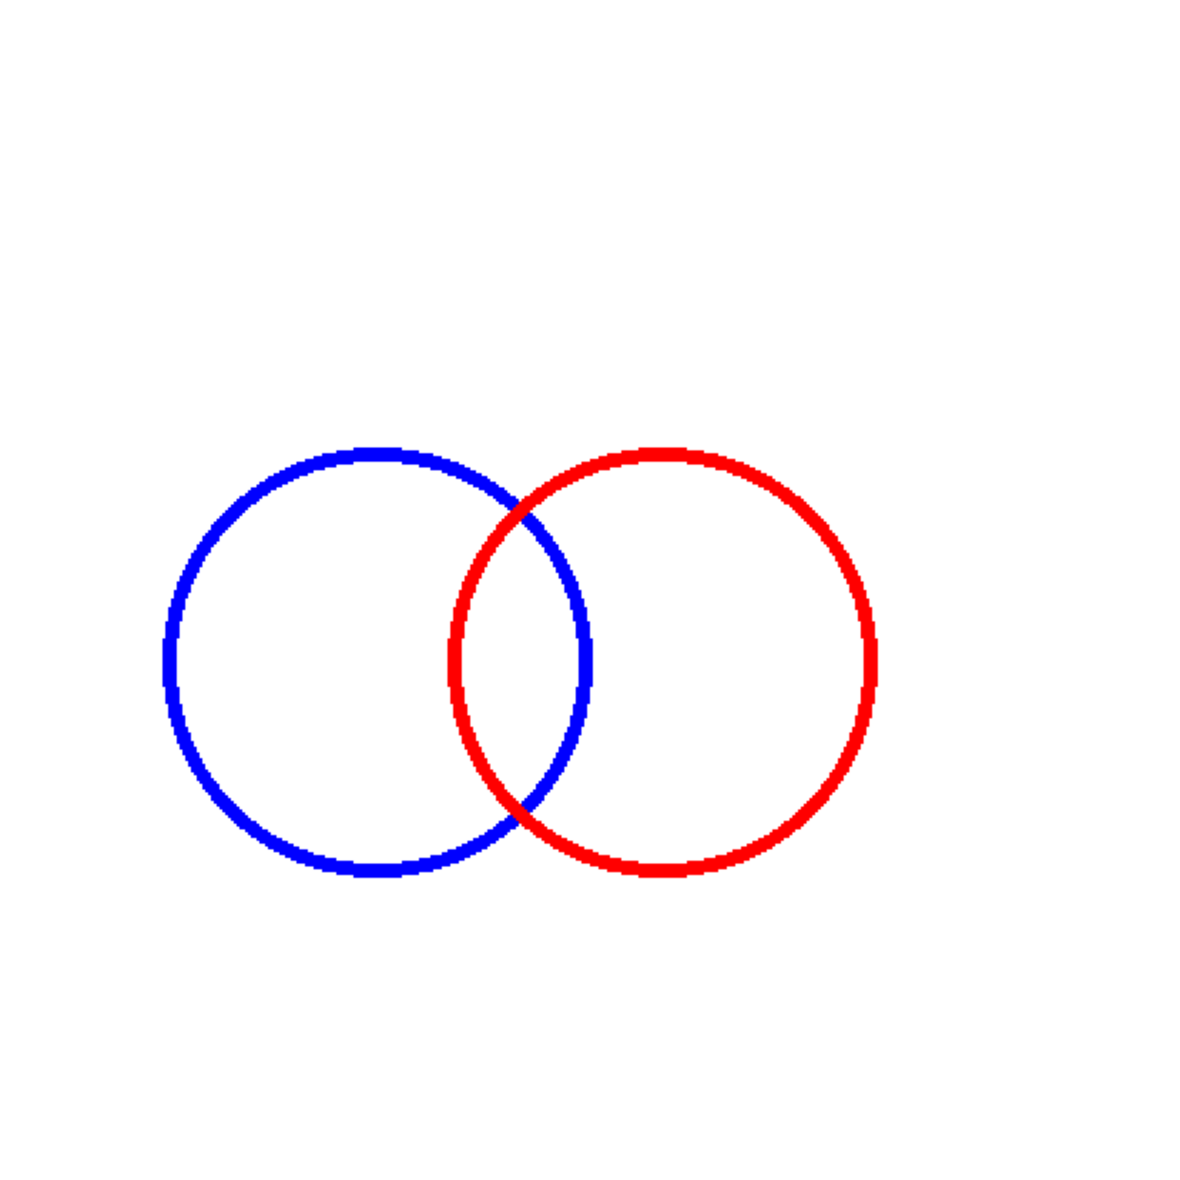


Question: Are these two circles overlapping, touching, or separated? Answer with ONE word only.
Correct Answer: overlapping
Gemini's Answer: Overlapping

Result: CORRECT


In [19]:
# Test: Two overlapping circles
img = Image.new('RGB', (400, 400), 'white')
draw = ImageDraw.Draw(img)

# Draw two overlapping circles
draw.ellipse([50, 150, 200, 300], outline='blue', fill=None, width=5)
draw.ellipse([150, 150, 300, 300], outline='red', fill=None, width=5)

correct, answer = test_visual_task(
    img,
    "Are these two circles overlapping, touching, or separated? Answer with ONE word only.",
    "overlapping",
    "Circle Relationship (overlapping)"
)

results.append({
    'category': 'VLMsAreBlind',
    'task': 'Touching Circles',
    'correct': correct,
    'expected': 'overlapping',
    'actual': answer
})

## Test 3: Grid Counting

Can the model accurately count rows and columns in a grid?


Task: Grid Counting (5x7)


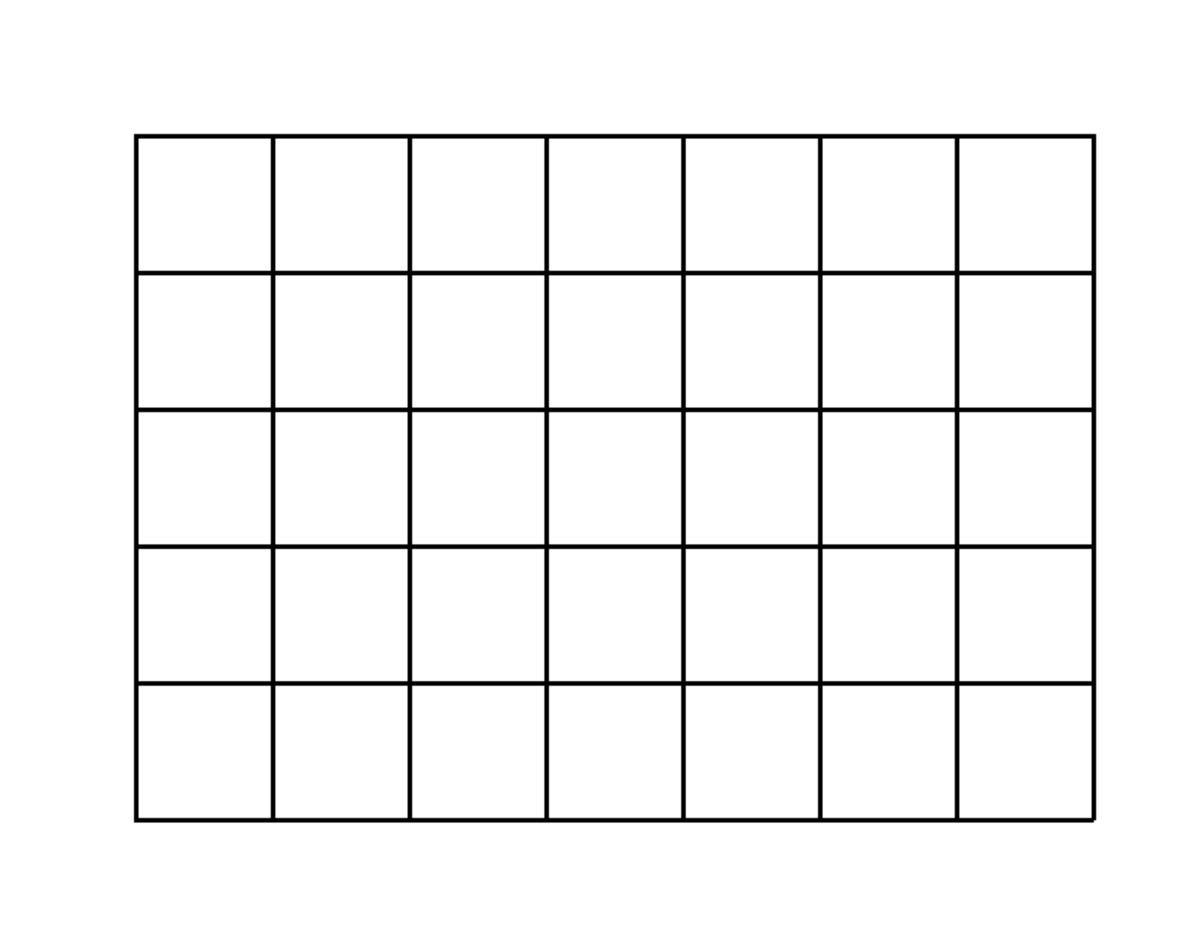


Question: How many rows and columns are in this grid? Answer in format 'X rows, Y columns'.
Correct Answer: 5 rows, 7 columns
Gemini's Answer: 5 rows, 7 columns

Result: CORRECT


In [20]:
# Create a 5x7 grid
img = Image.new('RGB', (500, 400), 'white')
draw = ImageDraw.Draw(img)

rows = 5
cols = 7
cell_width = 60
cell_height = 60
start_x = 50
start_y = 50

# Draw grid
for i in range(rows + 1):
    y = start_y + i * cell_height
    draw.line([(start_x, y), (start_x + cols * cell_width, y)], fill='black', width=2)

for j in range(cols + 1):
    x = start_x + j * cell_width
    draw.line([(x, start_y), (x, start_y + rows * cell_height)], fill='black', width=2)

correct, answer = test_visual_task(
    img,
    "How many rows and columns are in this grid? Answer in format 'X rows, Y columns'.",
    "5 rows, 7 columns",
    "Grid Counting (5x7)"
)

results.append({
    'category': 'VLMsAreBlind',
    'task': 'Grid Counting',
    'correct': correct,
    'expected': '5 rows, 7 columns',
    'actual': answer
})

## Test 4: Nested Squares

Can the model count squares nested inside each other without touching?


Task: Nested Squares (3 squares)


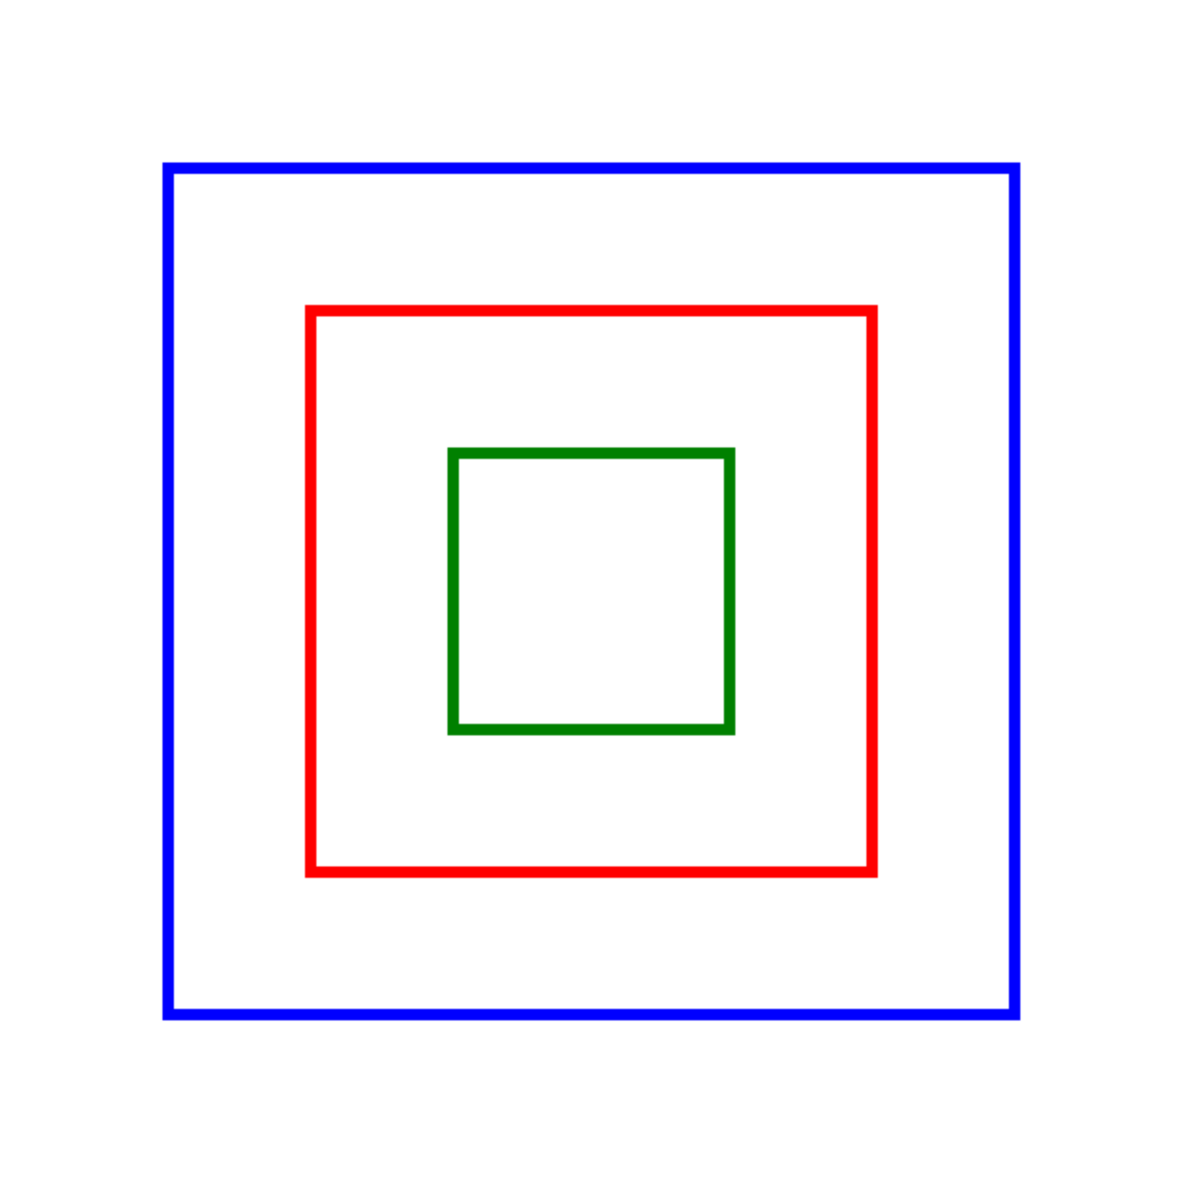


Question: How many squares are in this image? Count all squares including nested ones.
Correct Answer: 3
Gemini's Answer: 3

Result: CORRECT


In [21]:
# Create 3 nested squares
img = Image.new('RGB', (400, 400), 'white')
draw = ImageDraw.Draw(img)

# Draw 3 nested squares with gaps
draw.rectangle([50, 50, 350, 350], outline='blue', width=4)
draw.rectangle([100, 100, 300, 300], outline='red', width=4)
draw.rectangle([150, 150, 250, 250], outline='green', width=4)

correct, answer = test_visual_task(
    img,
    "How many squares are in this image? Count all squares including nested ones.",
    "3",
    "Nested Squares (3 squares)"
)

results.append({
    'category': 'VLMsAreBlind',
    'task': 'Nested Squares',
    'correct': correct,
    'expected': '3',
    'actual': answer
})

# Part 2: VLMsAreBiased - Memorization vs. Vision Tests

These tests check if Gemini relies on memorized knowledge ("cats have 4 legs") or actually counts what it sees in the image.

## Test 5: Modified Animal Legs

We'll create a simple cat drawing with 6 legs. Will the model count 6 or default to "cats have 4 legs"?


Task: Modified Animal: Cat with 6 legs


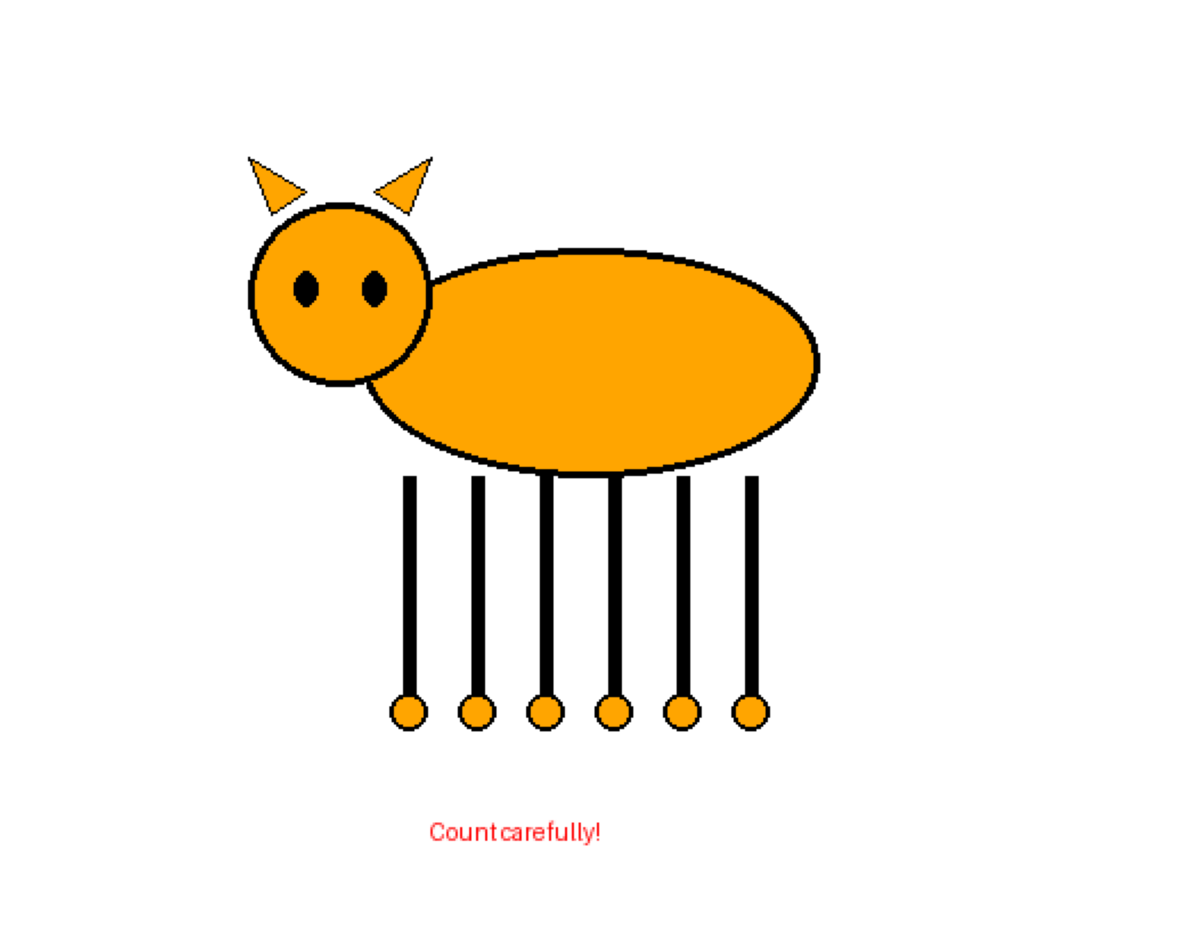


Question: Count the number of legs on this cat. Answer with ONLY the number.
Correct Answer: 6
Gemini's Answer: 6

Result: CORRECT


In [22]:
# Create a simple cat with 6 legs
img = Image.new('RGB', (500, 400), 'white')
draw = ImageDraw.Draw(img)

# Draw cat body (ellipse)
draw.ellipse([150, 100, 350, 200], fill='orange', outline='black', width=3)

# Draw cat head (circle)
draw.ellipse([100, 80, 180, 160], fill='orange', outline='black', width=3)

# Draw 6 legs (vertical lines with circles at bottom for paws)
leg_positions = [170, 200, 230, 260, 290, 320]
for x in leg_positions:
    draw.line([(x, 200), (x, 300)], fill='black', width=6)
    draw.ellipse([x-8, 295, x+8, 311], fill='orange', outline='black', width=2)

# Draw ears
draw.polygon([(110, 85), (100, 60), (125, 75)], fill='orange', outline='black')
draw.polygon([(155, 75), (180, 60), (170, 85)], fill='orange', outline='black')

# Draw eyes
draw.ellipse([120, 110, 130, 125], fill='black')
draw.ellipse([150, 110, 160, 125], fill='black')

# Add text annotation
draw.text((180, 350), "Count carefully!", fill='red', font=None)

correct, answer = test_visual_task(
    img,
    "Count the number of legs on this cat. Answer with ONLY the number.",
    "6",
    "Modified Animal: Cat with 6 legs"
)

results.append({
    'category': 'VLMsAreBiased',
    'task': 'Modified Animals',
    'correct': correct,
    'expected': '6',
    'actual': answer
})

## Test 6: Modified Brand Logo (Adidas)

Adidas typically has 3 stripes. Let's draw 2 stripes and see if Gemini counts what it sees or defaults to "Adidas has 3 stripes".


Task: Modified Logo: Shoe with 2 stripes (not 3)


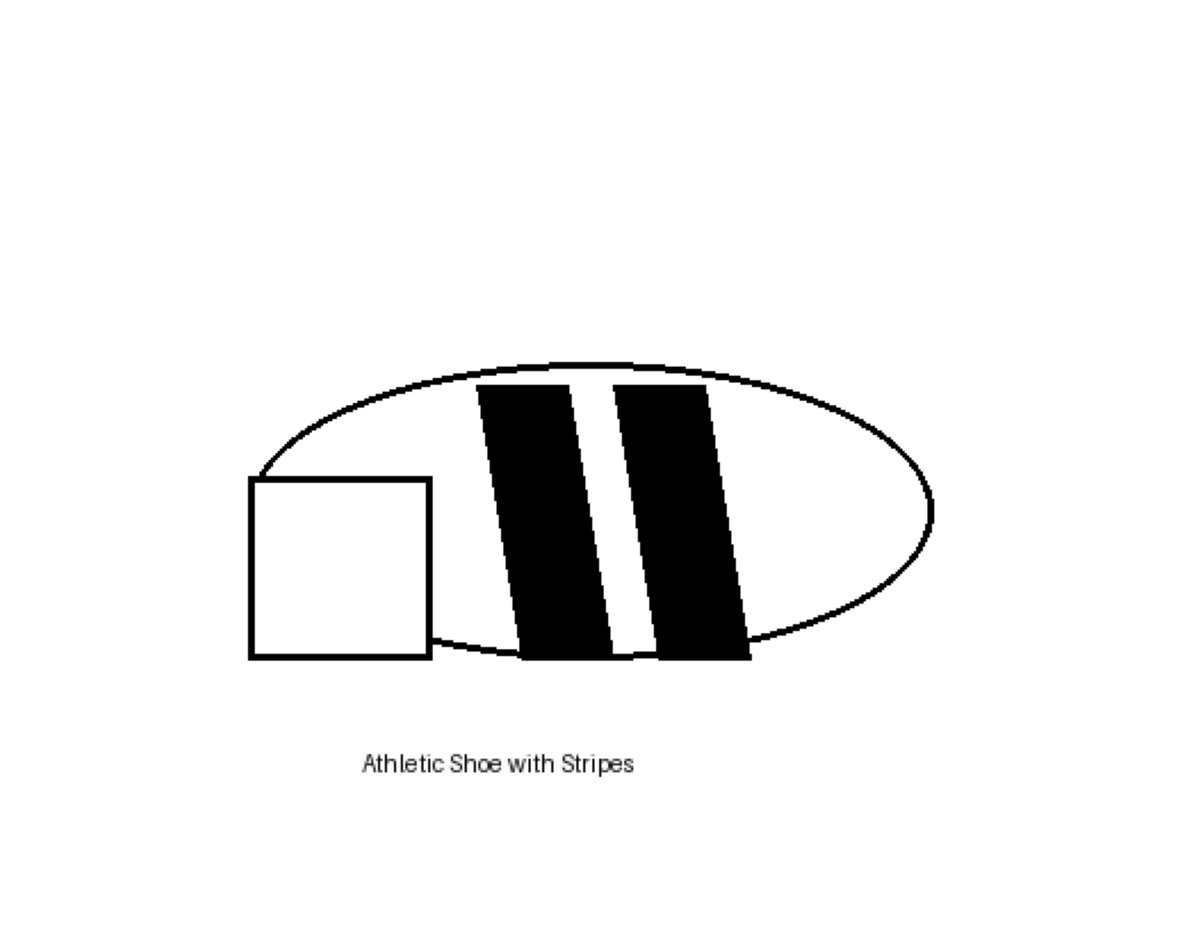


Question: How many black diagonal stripes are on this shoe? Answer with ONLY the number.
Correct Answer: 2
Gemini's Answer: 2

Result: CORRECT


In [23]:
# Create simplified shoe with 2 stripes
img = Image.new('RGB', (500, 400), 'white')
draw = ImageDraw.Draw(img)

# Draw shoe outline (simplified)
draw.ellipse([100, 150, 400, 280], fill='white', outline='black', width=3)
draw.rectangle([100, 200, 180, 280], fill='white', outline='black', width=3)

# Draw 2 diagonal stripes (not 3!)
stripe_width = 20
draw.polygon([
    (200, 160), (240, 160),
    (260, 280), (220, 280)
], fill='black')

draw.polygon([
    (260, 160), (300, 160),
    (320, 280), (280, 280)
], fill='black')

# Add text
draw.text((150, 320), "Athletic Shoe with Stripes", fill='black', font=None)

correct, answer = test_visual_task(
    img,
    "How many black diagonal stripes are on this shoe? Answer with ONLY the number.",
    "2",
    "Modified Logo: Shoe with 2 stripes (not 3)"
)

results.append({
    'category': 'VLMsAreBiased',
    'task': 'Modified Logos',
    'correct': correct,
    'expected': '2',
    'actual': answer
})

## Test 7: Modified USA Flag

The USA flag has 13 stripes. Let's create one with 7 stripes and see if the model counts accurately.


Task: Modified Flag: USA-style flag with 7 stripes (not 13)


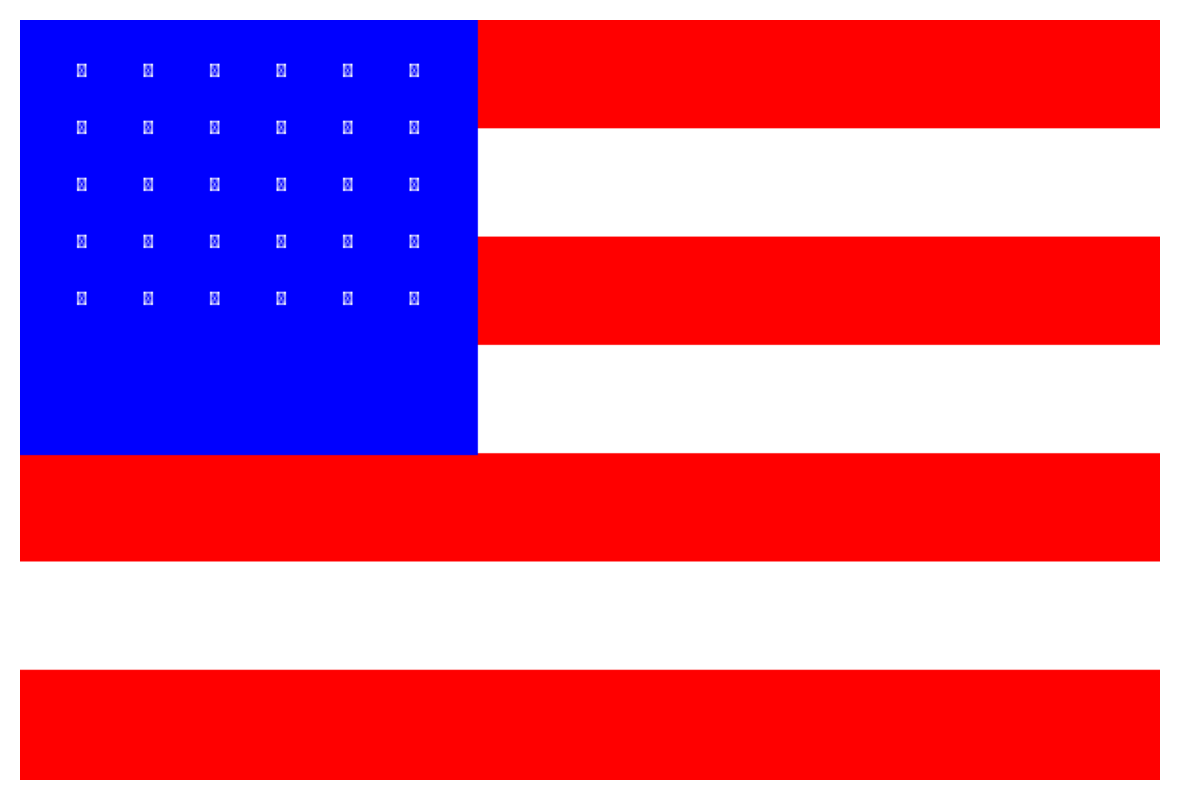


Question: How many horizontal stripes (red and white combined) are on this flag? Answer with ONLY the number.
Correct Answer: 7
Gemini's Answer: 7

Result: CORRECT


In [24]:
# Create modified USA flag with 7 stripes instead of 13
img = Image.new('RGB', (600, 400), 'white')
draw = ImageDraw.Draw(img)

stripe_height = 400 // 7

# Draw 7 alternating red and white stripes
for i in range(7):
    color = 'red' if i % 2 == 0 else 'white'
    y0 = i * stripe_height
    y1 = (i + 1) * stripe_height
    draw.rectangle([0, y0, 600, y1], fill=color)

# Draw blue canton with stars
draw.rectangle([0, 0, 240, 4 * stripe_height], fill='blue')

# Add some stars (simplified)
for i in range(5):
    for j in range(6):
        x = 30 + j * 35
        y = 20 + i * 30
        draw.text((x, y), "★", fill='white', font=None)

correct, answer = test_visual_task(
    img,
    "How many horizontal stripes (red and white combined) are on this flag? Answer with ONLY the number.",
    "7",
    "Modified Flag: USA-style flag with 7 stripes (not 13)"
)

results.append({
    'category': 'VLMsAreBiased',
    'task': 'Modified Flags',
    'correct': correct,
    'expected': '7',
    'actual': answer
})

## Test 8: Modified Chess Position

A standard chess starting position has 16 pieces per side. Let's create a modified position and see if the model counts accurately.


Task: Modified Chess: Board with 5 black pieces


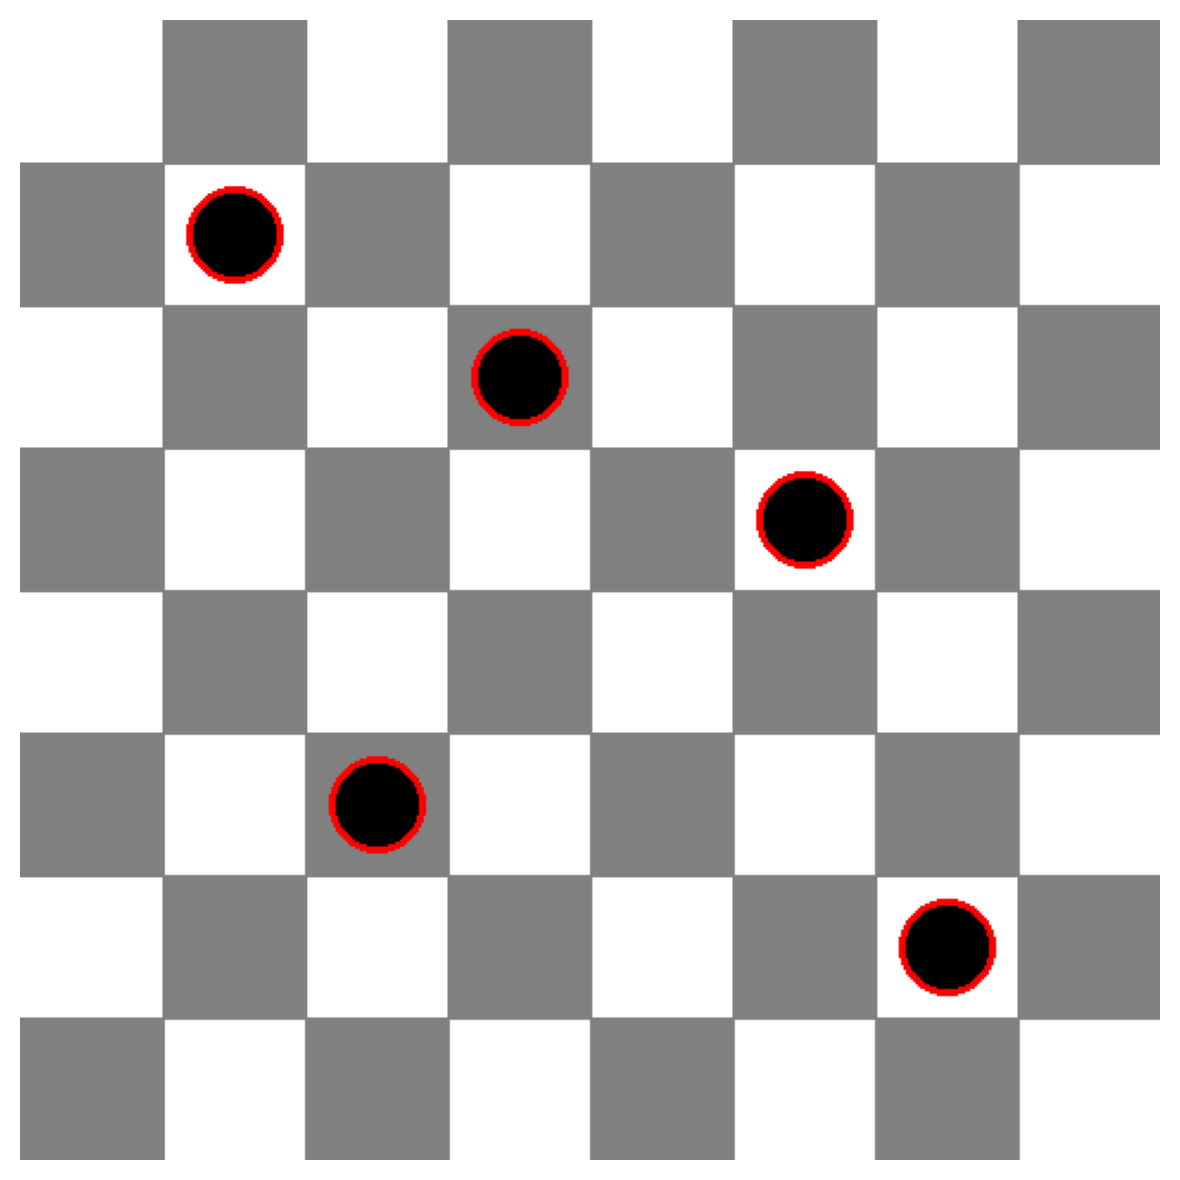


Question: How many black pieces are on this chess board? Answer with ONLY the number.
Correct Answer: 5
Gemini's Answer: 5

Result: CORRECT


In [25]:
# Create simplified chess board with fewer pieces
img = Image.new('RGB', (480, 480), 'white')
draw = ImageDraw.Draw(img)

cell_size = 60

# Draw checkerboard pattern
for row in range(8):
    for col in range(8):
        if (row + col) % 2 == 1:
            x0 = col * cell_size
            y0 = row * cell_size
            draw.rectangle([x0, y0, x0 + cell_size, y0 + cell_size], fill='gray')

# Place only 5 black pieces (circles) on the board
piece_positions = [(1, 1), (3, 2), (5, 3), (2, 5), (6, 6)]

for col, row in piece_positions:
    x = col * cell_size + cell_size // 2
    y = row * cell_size + cell_size // 2
    draw.ellipse([x-20, y-20, x+20, y+20], fill='black', outline='red', width=3)

correct, answer = test_visual_task(
    img,
    "How many black pieces are on this chess board? Answer with ONLY the number.",
    "5",
    "Modified Chess: Board with 5 black pieces"
)

results.append({
    'category': 'VLMsAreBiased',
    'task': 'Modified Chess',
    'correct': correct,
    'expected': '5',
    'actual': answer
})

# Results Summary

In [26]:
create_results_summary(results)



FINAL RESULTS SUMMARY

Overall Accuracy: 9/9 (100.0%)

By Category:
  VLMsAreBlind: 5/5 (100.0%)
  VLMsAreBiased: 4/4 (100.0%)

